In [1]:
import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from context_flux_no.simulations.pde.shallow_water import ParametrizedShallowWater1D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField
from context_flux_no.waveforms.step import (
    MultichannelWaveform,
    PeriodicRandomStepFunction1D,
)


jax.config.update("jax_default_device", jax.devices("gpu")[0])

2026-05-06 21:30:52,813 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


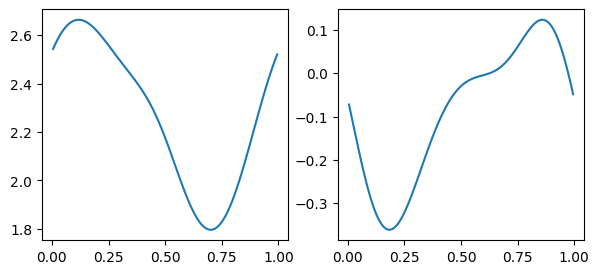

In [5]:
grf = GaussianRandomField(
    covariance_fns=[
        gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
        gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
    ],
    transforms=[gs.normalizer.LogNormal(), None],
)

x = jnp.arange(0.005, 1.005, 0.01)
u0 = grf.sample(x, jax.random.key(11))
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for i, ax in enumerate(axes):
    ax.plot(x, u0[i])

In [4]:
pde = ParametrizedShallowWater1D(0.5, 1.5, 12)
sol = pde.solve(
    lambda x: grf.sample(x, jax.random.key(0)),
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    bc="periodic",
)

2026-04-27 16:08:30,460 INFO CLAW: Solution 0 computed for time t=0.000000
2026-04-27 16:08:30,464 INFO CLAW: Solution 1 computed for time t=0.005000
2026-04-27 16:08:30,467 INFO CLAW: Solution 2 computed for time t=0.010000
2026-04-27 16:08:30,471 INFO CLAW: Solution 3 computed for time t=0.015000
2026-04-27 16:08:30,475 INFO CLAW: Solution 4 computed for time t=0.020000
2026-04-27 16:08:30,480 INFO CLAW: Solution 5 computed for time t=0.025000
2026-04-27 16:08:30,485 INFO CLAW: Solution 6 computed for time t=0.030000
2026-04-27 16:08:30,492 INFO CLAW: Solution 7 computed for time t=0.035000
2026-04-27 16:08:30,498 INFO CLAW: Solution 8 computed for time t=0.040000
2026-04-27 16:08:30,505 INFO CLAW: Solution 9 computed for time t=0.045000
2026-04-27 16:08:30,512 INFO CLAW: Solution 10 computed for time t=0.050000
2026-04-27 16:08:30,519 INFO CLAW: Solution 11 computed for time t=0.055000
2026-04-27 16:08:30,526 INFO CLAW: Solution 12 computed for time t=0.060000
2026-04-27 16:08:30,53

2026-04-27 16:08:30,545 INFO CLAW: Solution 15 computed for time t=0.075000
2026-04-27 16:08:30,551 INFO CLAW: Solution 16 computed for time t=0.080000
2026-04-27 16:08:30,556 INFO CLAW: Solution 17 computed for time t=0.085000
2026-04-27 16:08:30,562 INFO CLAW: Solution 18 computed for time t=0.090000
2026-04-27 16:08:30,567 INFO CLAW: Solution 19 computed for time t=0.095000
2026-04-27 16:08:30,572 INFO CLAW: Solution 20 computed for time t=0.100000
2026-04-27 16:08:30,577 INFO CLAW: Solution 21 computed for time t=0.105000
2026-04-27 16:08:30,581 INFO CLAW: Solution 22 computed for time t=0.110000
2026-04-27 16:08:30,586 INFO CLAW: Solution 23 computed for time t=0.115000
2026-04-27 16:08:30,590 INFO CLAW: Solution 24 computed for time t=0.120000
2026-04-27 16:08:30,594 INFO CLAW: Solution 25 computed for time t=0.125000
2026-04-27 16:08:30,598 INFO CLAW: Solution 26 computed for time t=0.130000
2026-04-27 16:08:30,602 INFO CLAW: Solution 27 computed for time t=0.135000
2026-04-27 1

In [5]:
sol

<xarray.Dataset> Size: 163kB
Dimensions:  (ic: 1, t: 101, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 162kB 1.242 1.301 1.364 ... 0.7007 0.7438
    coeffs   (param) float64 32B 0.5 1.5 12.0 1e-08

In [6]:
sol["values"].shape

(1, 101, 2, 100)

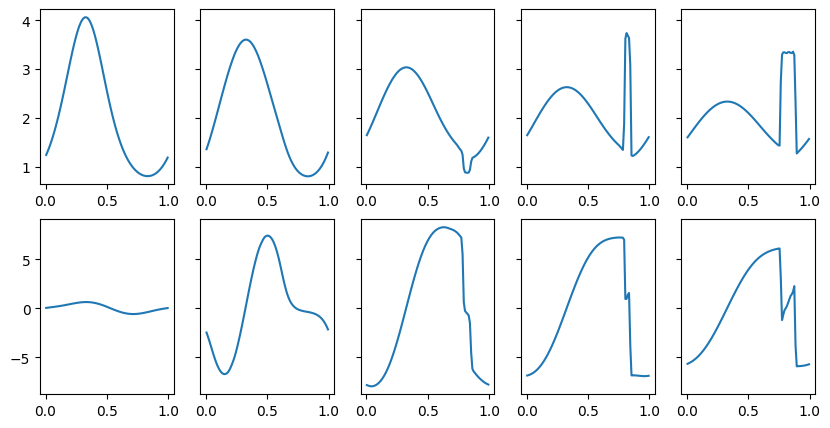

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5), sharey="row")
for i in range(axes.shape[1]):
    axes[0, i].plot(x, sol["values"][0, 4 * i, 0])
    axes[1, i].plot(x, sol["values"][0, 4 * i, 1])

In [8]:
dataset = generate_dataset(
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=ParametrizedShallowWater1D,
    initial_condition_fn=GaussianRandomField(
        covariance_fns=[
            gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
            gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
        ],
        transforms=[gs.normalizer.LogNormal(), None],
    ).sample,
    coeff_range_dict={
        "gamma": (0.5, 1.5),
        "alpha": (0.5, 1.5),
        "beta": (8, 12),
    },
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)

100%|██████████| 10/10 [00:31<00:00,  3.11s/it]
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/simulations/utils.py:70: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(solutions_all, "ic")  # "pde")


In [9]:
dataset

<xarray.Dataset> Size: 16MB
Dimensions:  (ic: 99, t: 101, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 16MB 0.7094 0.6901 0.672 ... 1.131 1.166
    coeffs   (ic, param) float64 3kB 0.5586 0.5107 9.35 ... 0.7107 9.103 1e-08

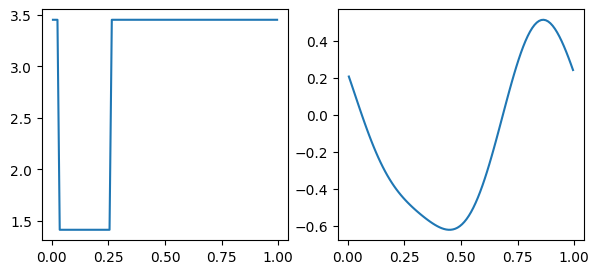

In [2]:
step = MultichannelWaveform(
    [
        PeriodicRandomStepFunction1D(value_min=0.5, value_max=4.5),
        GaussianRandomField(
            covariance_fns=[
                gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
            ],
        ),
    ]
)

x = jnp.arange(0.005, 1.005, 0.01)
u0 = step.sample(x, jax.random.key(0))
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for i, ax in enumerate(axes):
    ax.plot(x, u0[i])

In [3]:
pde = ParametrizedShallowWater1D(0.5, 1.5, 12)
sol = pde.solve(
    lambda x: step.sample(x, jax.random.key(0)),
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    bc="periodic",
)

2026-05-06 20:36:03,625 INFO CLAW: Solution 0 computed for time t=0.000000
2026-05-06 20:36:03,631 INFO CLAW: Solution 1 computed for time t=0.005000
2026-05-06 20:36:03,636 INFO CLAW: Solution 2 computed for time t=0.010000
2026-05-06 20:36:03,641 INFO CLAW: Solution 3 computed for time t=0.015000
2026-05-06 20:36:03,646 INFO CLAW: Solution 4 computed for time t=0.020000
2026-05-06 20:36:03,651 INFO CLAW: Solution 5 computed for time t=0.025000


2026-05-06 20:36:03,656 INFO CLAW: Solution 6 computed for time t=0.030000
2026-05-06 20:36:03,661 INFO CLAW: Solution 7 computed for time t=0.035000
2026-05-06 20:36:03,666 INFO CLAW: Solution 8 computed for time t=0.040000
2026-05-06 20:36:03,671 INFO CLAW: Solution 9 computed for time t=0.045000
2026-05-06 20:36:03,675 INFO CLAW: Solution 10 computed for time t=0.050000
2026-05-06 20:36:03,680 INFO CLAW: Solution 11 computed for time t=0.055000
2026-05-06 20:36:03,685 INFO CLAW: Solution 12 computed for time t=0.060000
2026-05-06 20:36:03,690 INFO CLAW: Solution 13 computed for time t=0.065000
2026-05-06 20:36:03,695 INFO CLAW: Solution 14 computed for time t=0.070000
2026-05-06 20:36:03,700 INFO CLAW: Solution 15 computed for time t=0.075000
2026-05-06 20:36:03,704 INFO CLAW: Solution 16 computed for time t=0.080000
2026-05-06 20:36:03,709 INFO CLAW: Solution 17 computed for time t=0.085000
2026-05-06 20:36:03,713 INFO CLAW: Solution 18 computed for time t=0.090000
2026-05-06 20:36

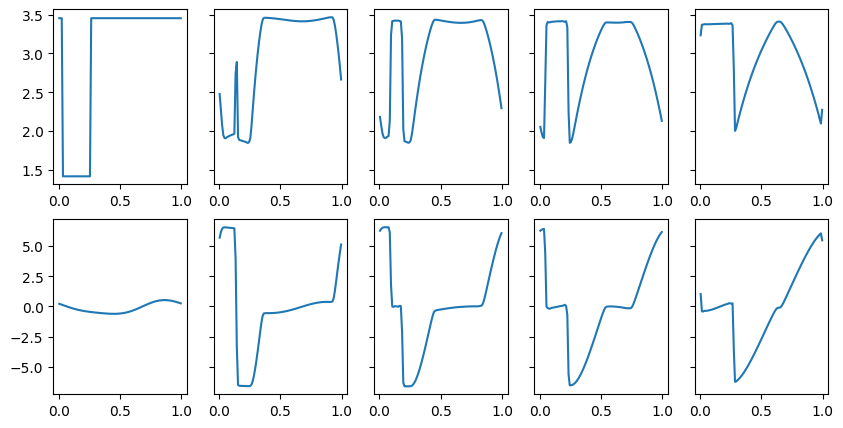

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5), sharey="row")
for i in range(axes.shape[1]):
    axes[0, i].plot(x, sol["values"][0, 4 * i, 0])
    axes[1, i].plot(x, sol["values"][0, 4 * i, 1])

In [2]:
dataset = generate_dataset(
    n_coeffs=100,
    n_ics_per_coeff=100,
    pde_factory=ParametrizedShallowWater1D,
    initial_condition_fn=MultichannelWaveform(
        [
            PeriodicRandomStepFunction1D(value_min=0.5, value_max=4.5),
            GaussianRandomField(
                covariance_fns=[
                    gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
                ],
            ),
        ]
    ).sample,
    coeff_range_dict={
        "gamma": (0.5, 1.5),
        "alpha": (0.5, 1.5),
        "beta": (8, 12),
    },
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    seed=10,
)

100%|██████████| 100/100 [45:26<00:00, 27.27s/it]
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/simulations/utils.py:70: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(solutions_all, "ic")  # "pde")


In [3]:
dataset

<xarray.Dataset> Size: 2GB
Dimensions:  (ic: 9996, t: 101, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 2GB 3.525 3.525 3.525 ... 1.318 1.404 1.489
    coeffs   (ic, param) float64 320kB 1.195 0.5431 9.602 ... 1.046 8.158 1e-08

In [4]:
dataset.to_netcdf(
    "../../data/shallow_water_1d_test_step_grf_seed=10.hdf5", engine="h5netcdf"
)

In [6]:
dataset["values"].shape

(9996, 101, 2, 100)

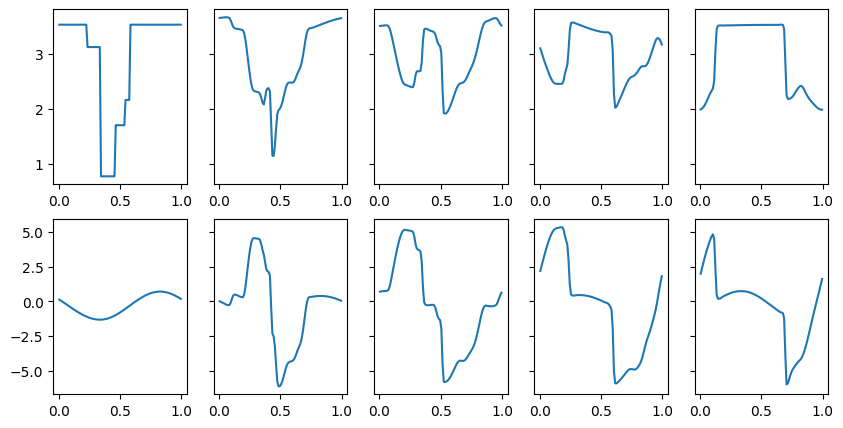

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5), sharey="row")
for i in range(axes.shape[1]):
    axes[0, i].plot(dataset.coords["x"], dataset["values"][0, 4 * i, 0])
    axes[1, i].plot(dataset.coords["x"], dataset["values"][0, 4 * i, 1])